In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Task 1: Dataset Selection and Schema Report

In [ ]:
# Dataset Information

# Dataset name: House Price Prediction  
# Source: Kaggle  
# Source URL: https://www.kaggle.com/datasets/shree1992/housedata  
# License: Unknown (as listed on Kaggle)

# Why I Chose This Dataset

# I chose this dataset because it contains 4,600 house records and includes both
# numeric and categorical variables. The dataset has useful features such as house
# price, number of bedrooms and bathrooms, living area, property condition, city,
# and street.

# It is suitable for this assignment because it allows me to practice data
# cleaning, Pandas transformations, NumPy computations, and exploratory data
# analysis while investigating a practical question about house prices.

# Analysis Question

# How do living space and location relate to house prices?

# In this task, I will inspect the dataset's shape, column names, data types,
# missing values, and unique values before cleaning or transforming the data.

In [ ]:
# Load the dataset and print its shape, column names, and dtypes.

In [6]:
df = pd.read_csv("../data/raw/data.csv")
df.head

<bound method NDFrame.head of                      date         price  bedrooms  bathrooms  sqft_living  \
0     2014-05-02 00:00:00  3.130000e+05       3.0       1.50         1340   
1     2014-05-02 00:00:00  2.384000e+06       5.0       2.50         3650   
2     2014-05-02 00:00:00  3.420000e+05       3.0       2.00         1930   
3     2014-05-02 00:00:00  4.200000e+05       3.0       2.25         2000   
4     2014-05-02 00:00:00  5.500000e+05       4.0       2.50         1940   
...                   ...           ...       ...        ...          ...   
4595  2014-07-09 00:00:00  3.081667e+05       3.0       1.75         1510   
4596  2014-07-09 00:00:00  5.343333e+05       3.0       2.50         1460   
4597  2014-07-09 00:00:00  4.169042e+05       3.0       2.50         3010   
4598  2014-07-10 00:00:00  2.034000e+05       4.0       2.00         2090   
4599  2014-07-10 00:00:00  2.206000e+05       3.0       2.50         1490   

      sqft_lot  floors  waterfront  view  con

In [8]:
df.shape

(4600, 18)

In [9]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='str')

In [10]:
df.dtypes

date                 str
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
street               str
city                 str
statezip             str
country              str
dtype: object

In [ ]:
# Report null counts and unique-value counts per column.

In [18]:
null_counts = df.isnull().sum()

print("Null values per column:")
print(null_counts)

Null values per column:
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64


In [19]:
unique_value = df.nunique(dropna = False)

print("Unique values:")
print(unique_value)

Unique values:
date               70
price            1741
bedrooms           10
bathrooms          26
sqft_living       566
sqft_lot         3113
floors              6
waterfront          2
view                5
condition           5
sqft_above        511
sqft_basement     207
yr_built          115
yr_renovated       60
street           4525
city               44
statezip           77
country             1
dtype: int64


In [ ]:
# Task 2: Data cleaning

In [20]:
clean_df = df.copy()

print("Shape before cleaning:", clean_df.shape)

Shape before cleaning: (4600, 18)


In [ ]:
# Fix Date Dtype

In [21]:
print("Date dtype before:")
print(clean_df["date"].dtype)


clean_df["date"] = pd.to_datetime(
    clean_df["date"],
    errors="coerce"
)


print("\nDate dtype after:")
print(clean_df["date"].dtype)


print("\nInvalid dates:")
print(clean_df["date"].isnull().sum())

Date dtype before:
str

Date dtype after:
datetime64[us]

Invalid dates:
0


In [ ]:
# Handle zero-price values

In [23]:
zero_price_count = (clean_df["price"] == 0).sum()

print("Zero-price records:", zero_price_count)

Zero-price records: 49


In [24]:
# A zero sale price cannot be meaningfully used in this house-price analysis,
# so these values are treated as missing and the rows are removed.

clean_df.loc[
    clean_df["price"] == 0,
    "price"
] = np.nan


clean_df = clean_df.dropna(
    subset=["price"]
).copy()


print("Shape after removing zero-price records:")
print(clean_df.shape)

Shape after removing zero-price records:
(4551, 18)


In [ ]:
# Fix bedroom dtype

In [25]:
print("Bedrooms dtype before:")
print(clean_df["bedrooms"].dtype)


clean_df["bedrooms"] = clean_df["bedrooms"].astype("int64")


print("\nBedrooms dtype after:")
print(clean_df["bedrooms"].dtype)

Bedrooms dtype before:
float64

Bedrooms dtype after:
int64


In [ ]:
# Convert categorical variables

In [26]:
categorical_columns = [
    "city",
    "statezip",
    "country"
]


for column in categorical_columns:
    clean_df[column] = clean_df[column].astype("category")


print(clean_df[categorical_columns].dtypes)

city        category
statezip    category
country     category
dtype: object


In [ ]:
# Check duplicates

In [27]:
duplicate_count = clean_df.duplicated().sum()

print("Duplicate rows found:", duplicate_count)

Duplicate rows found: 0


In [ ]:
# Verify cleaning

In [28]:
print("Shape after cleaning:")
print(clean_df.shape)


print("\nRemaining null values:")
print(clean_df.isnull().sum())


print("\nTotal remaining null values:")
print(clean_df.isnull().sum().sum())


print("\nData types after cleaning:")
print(clean_df.dtypes)

Shape after cleaning:
(4551, 18)

Remaining null values:
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

Total remaining null values:
0

Data types after cleaning:
date             datetime64[us]
price                   float64
bedrooms                  int64
bathrooms               float64
sqft_living               int64
sqft_lot                  int64
floors                  float64
waterfront                int64
view                      int64
condition                 int64
sqft_above                int64
sqft_basement             int64
yr_built                  int64
yr_renovated              int64
street                      str
city                   category
statezip        

In [ ]:
# TASK 3: Feature Engineering with GroupBy and Merge

In [29]:
print("Shape before GroupBy and merge:")
print(clean_df.shape)

Shape before GroupBy and merge:
(4551, 18)


In [ ]:
# GroupBy aggregation

In [30]:
city_stats = (
    clean_df
    .groupby(
        "city",
        observed=False
    )
    .agg(
        city_listing_count=("price", "size"),
        city_avg_price=("price", "mean"),
        city_median_price=("price", "median"),
        city_avg_sqft_living=("sqft_living", "mean")
    )
    .reset_index()
)


city_stats.head(10)

,city,city_listing_count,city_avg_price,city_median_price,city_avg_sqft_living
0,Algona,5,2.072880e+05,230000.0,1608.600000
1,Auburn,175,3.010510e+05,276000.0,2019.920000
2,Beaux Arts Village,1,7.450000e+05,745000.0,1490.000000
3,Bellevue,281,8.622551e+05,725000.0,2673.113879
4,Black Diamond,8,3.820562e+05,326500.0,1807.500000
5,Bothell,33,4.814419e+05,458000.0,2319.393939
6,Burien,72,3.586402e+05,287475.0,1800.486111
7,Carnation,22,5.087520e+05,432175.0,2392.454545
8,Clyde Hill,9,1.615711e+06,1325000.0,3652.222222
9,Covington,42,3.032835e+05,249700.0,1766.666667


In [ ]:
# Merge statistics back

In [31]:
clean_df = clean_df.merge(
    city_stats,
    on="city",
    how="left",
    validate="many_to_one"
)


print("Shape after GroupBy and merge:")
print(clean_df.shape)

Shape after GroupBy and merge:
(4551, 22)


In [ ]:
# Create another useful feature

In [32]:
# Positive values mean the house is more expensive
# than the average house in its city.

clean_df["price_vs_city_avg"] = (
    clean_df["price"]
    - clean_df["city_avg_price"]
)


clean_df[
    [
        "city",
        "price",
        "city_avg_price",
        "price_vs_city_avg"
    ]
].head()

,city,price,city_avg_price,price_vs_city_avg
0,Shoreline,313000.0,420392.364047,-1.073924e+05
1,Seattle,2384000.0,584294.898165,1.799705e+06
2,Kent,342000.0,441880.990543,-9.988099e+04
3,Bellevue,420000.0,862255.052017,-4.422551e+05
4,Redmond,550000.0,667649.534781,-1.176495e+05


In [ ]:
# Pivot table

In [33]:
print("Main dataframe shape before pivot:")
print(clean_df.shape)


condition_waterfront_pivot = clean_df.pivot_table(
    index="condition",
    columns="waterfront",
    values="price",
    aggfunc="mean"
)


condition_waterfront_pivot = (
    condition_waterfront_pivot.rename(
        columns={
            0: "Non-waterfront",
            1: "Waterfront"
        }
    )
)


print("\nPivot table shape:")
print(condition_waterfront_pivot.shape)


condition_waterfront_pivot.round(2)

Main dataframe shape before pivot:
(4551, 23)

Pivot table shape:
(5, 2)


waterfront,Non-waterfront,Waterfront
condition,,
1,306633.33,NaN
2,260832.00,2555000.00
3,546761.77,1968812.50
4,536462.05,935100.00
5,646010.60,1498833.33


In [ ]:
# Task 4: NumPy-Based Computation

In [ ]:
# Convert to NumPy

In [34]:
price_array = clean_df["price"].to_numpy(
    dtype=float
)


print(type(price_array))
print(price_array[:10])

<class 'numpy.ndarray'>
[ 313000. 2384000.  342000.  420000.  550000.  490000.  335000.  482000.
  452500.  640000.]


In [ ]:
# NumPy vectorized calculation

In [35]:
price_mean = np.mean(price_array)
price_std = np.std(price_array)


# Vectorized calculation using NumPy broadcasting.
price_zscore = (
    price_array - price_mean
) / price_std

In [ ]:
# Required NumPy statistics

In [36]:
print("Mean:")
print(np.mean(price_zscore))


print("\nStandard deviation:")
print(np.std(price_zscore))


print("\nMinimum:")
print(np.min(price_zscore))


print("\nMaximum:")
print(np.max(price_zscore))

Mean:
1.28025718154973e-16

Standard deviation:
1.0

Minimum:
-0.9755935534440741

Maximum:
46.167007529366735


In [ ]:
# Add result to dataframe

In [37]:
clean_df["price_zscore"] = price_zscore


print("Shape after adding price_zscore:")
print(clean_df.shape)


clean_df[
    [
        "price",
        "price_zscore"
    ]
].head()

Shape after adding price_zscore:
(4551, 24)


,price,price_zscore
0,313000.0,-0.434332
1,2384000.0,3.238514
2,342000.0,-0.382902
3,420000.0,-0.244571
4,550000.0,-0.014021


In [ ]:
# Task 5: Exploratory Visualization

In [ ]:
# Calculate living area/price correlation

In [38]:
living_price_corr = clean_df[
    "sqft_living"
].corr(
    clean_df["price"]
)


print(
    "Correlation between living area and price:",
    round(living_price_corr, 3)
)

Correlation between living area and price: 0.445


In [ ]:
# Chart 1

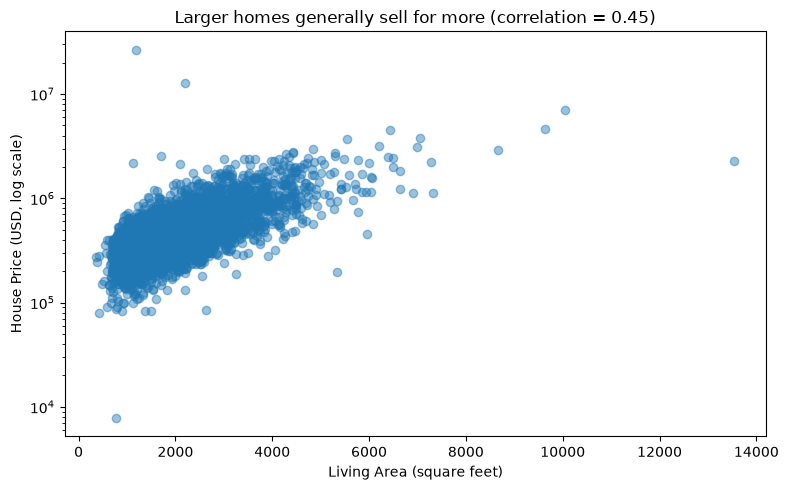

In [45]:
plt.figure(
    figsize=(8, 5)
)


plt.scatter(
    clean_df["sqft_living"],
    clean_df["price"],
    alpha=0.45
)


# A log scale makes the main pattern easier to see
# while keeping unusually expensive houses in the analysis.
plt.yscale("log")


plt.xlabel(
    "Living Area (square feet)"
)

plt.ylabel(
    "House Price (USD, log scale)"
)


plt.title(
    f"Larger homes generally sell for more "
    f"(correlation = {living_price_corr:.2f})"
)


plt.tight_layout()


plt.savefig(
    "../Reports/a2_chart1.png",
    dpi=150,
    bbox_inches="tight"
)


plt.show()

In [ ]:
# Chart 2 data

In [40]:
city_chart_data = (
    city_stats[
        city_stats["city_listing_count"] >= 50
    ]
    .copy()
    .sort_values("city_avg_price")
)


city_chart_data

,city,city_listing_count,city_avg_price,city_median_price,city_avg_sqft_living
14,Federal Way,145,2.958854e+05,264950.000000,2067.027586
1,Auburn,175,3.010510e+05,276000.000000,2019.920000
10,Des Moines,58,3.049925e+05,256975.000000,1812.620690
21,Maple Valley,95,3.400168e+05,321000.000000,2086.000000
6,Burien,72,3.586402e+05,287475.000000,1800.486111
32,Renton,291,3.796323e+05,345000.000000,2108.230241
27,North Bend,50,3.995657e+05,394250.000000,1995.400000
36,Shoreline,123,4.203924e+05,360000.000000,1774.837398
18,Kent,184,4.418810e+05,283600.000000,1980.190217
17,Kenmore,65,4.543786e+05,438000.000000,2122.076923


In [ ]:
# Find highest and lowest city

In [41]:
highest_city_row = city_chart_data.loc[
    city_chart_data["city_avg_price"].idxmax()
]


lowest_city_row = city_chart_data.loc[
    city_chart_data["city_avg_price"].idxmin()
]


highest_city = str(
    highest_city_row["city"]
)

highest_city_price = (
    highest_city_row["city_avg_price"]
)


lowest_city = str(
    lowest_city_row["city"]
)

lowest_city_price = (
    lowest_city_row["city_avg_price"]
)


print(
    f"Highest average-price city: "
    f"{highest_city} "
    f"(${highest_city_price:,.0f})"
)


print(
    f"Lowest average-price city: "
    f"{lowest_city} "
    f"(${lowest_city_price:,.0f})"
)

Highest average-price city: Mercer Island ($1,178,638)
Lowest average-price city: Federal Way ($295,885)


In [ ]:
# Chart 2

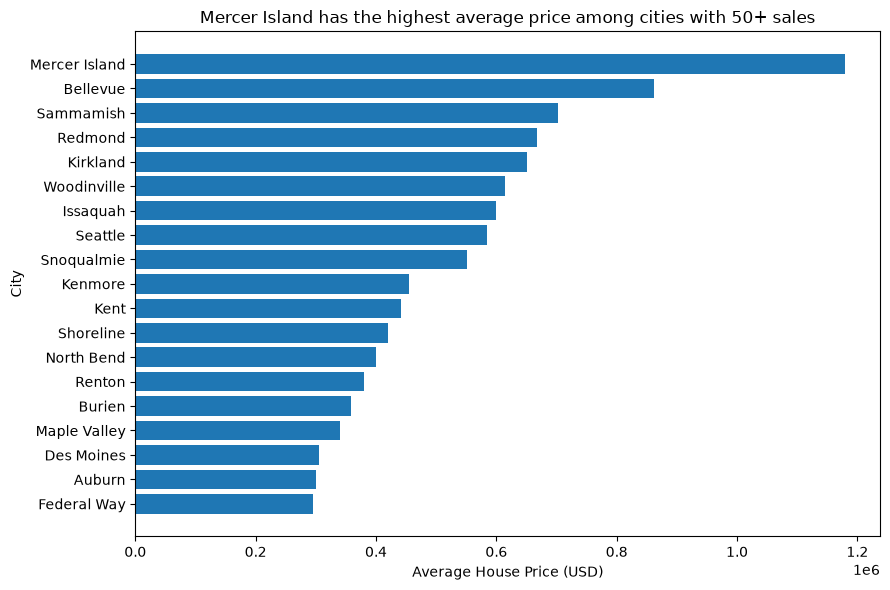

In [46]:
plt.figure(
    figsize=(9, 6)
)


plt.barh(
    city_chart_data["city"].astype(str),
    city_chart_data["city_avg_price"]
)


plt.xlabel(
    "Average House Price (USD)"
)

plt.ylabel(
    "City"
)


plt.title(
    f"{highest_city} has the highest average price "
    f"among cities with 50+ sales"
)


plt.tight_layout()


plt.savefig(
    "../Reports/a2_chart2.png",
    dpi=150,
    bbox_inches="tight"
)


plt.show()

In [ ]:
# Task 6: Cleaned Dataset and Report

In [ ]:
# Save processed dataset

In [53]:
processed_path = "../data/processed/house_prices_cleaned_featured.csv"

clean_df.to_csv(
    processed_path,
    index=False
)

print("Processed dataset saved to:")
print(processed_path)

print("\nFinal dataframe shape:")
print(clean_df.shape)

Processed dataset saved to:
../data/processed/house_prices_cleaned_featured.csv

Final dataframe shape:
(4551, 24)
